# Measurement-noise sensitivity

Dedicated paper experiment for white and spatially correlated Gaussian noise. It sweeps `SNR x lambda` over 10 independent noise realizations. The aggregated means and standard deviations are written to `tables/noise_sensitivity.csv`, while individual runs are preserved in `tables/noise_sensitivity_realizations.csv`; the global paper notebook no longer executes this experiment.


## Configuration and prerequisites

Run the Sentinel-2 download section of `test-resample-paper.ipynb` once if the four `data/<scene>_data.zarr` caches do not exist. The synthetic-detector products are then built or reused here. Set `RUN_EXPERIMENT=True` only when ready for the complete sweep (1,212 reconstructions with the default configuration).


In [1]:
from pathlib import Path
import os
import time
import json
import warnings

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import xarray as xr
import pyproj
import pystac_client

from scipy import ndimage
from scipy.ndimage import gaussian_filter
from scipy.interpolate import RegularGridInterpolator, griddata
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from skimage.metrics import structural_similarity as ssim
from skimage import exposure

try:
    from healpix_resample import PSFResampler
except Exception as exc:
    PSFResampler = None
    warnings.warn(f"Could not import PSFResampler: {exc}")

try:
    # fwhm_to_scale()/recommend_npt() fix the two bugs found in the paper review
    # (see planning notes / Thomas Davison's review + effective_kernel_geometry.ipynb):
    #   (1) sigma_m was being fed an intended FWHM directly, with no conversion to
    #       the scale `s` the kernel w(d)=exp(-2 d^2/s^2) actually expects
    #       (s = FWHM / sqrt(2 ln 2), NOT FWHM itself -- see psf_geometry.py).
    #   (2) Npt was fixed at 9 regardless of kernel width, which silently
    #       truncates any kernel much wider than about one cell. At the old
    #       (buggy) scale=12.6 this kept only 75% of the kernel's mass at
    #       Npt=9; the +50% mismatch arm kept under 50%.
    from healpix_resample import fwhm_to_scale, scale_to_fwhm, recommend_npt
except Exception as exc:
    fwhm_to_scale = scale_to_fwhm = recommend_npt = None
    warnings.warn(f"Could not import fwhm_to_scale/recommend_npt: {exc}")

try:
    import healpy as hp
except Exception as exc:
    hp = None
    warnings.warn(f"Could not import healpy: {exc}")

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "test-resample-paper.ipynb").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "notebooks"
DATA_DIR   = NOTEBOOK_DIR / "data"
# Patches for the paper's scenes, mirrored so they stay addressable.
# Virtual-hosted-style URL: OVH rejects path-style for anonymous requests, and
# bucket listing is not public, so read specific objects over plain HTTPS using
# the consolidated metadata. No credentials required.
MIRROR_BASE = ("https://grid4earth.s3.gra.io.cloud.ovh.net"
               "/public/eopf-mirror/sentinel-2-l2a/patches")
FIG_DIR    = NOTEBOOK_DIR / "figures"
TABLE_DIR  = NOTEBOOK_DIR / "tables"
for d in [DATA_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(exist_ok=True)

RANDOM_SEED  = 1234
np.random.seed(RANDOM_SEED)

# ── Paper default parameters ─────────────────────────────────────────────────
HEALPIX_LEVEL = 20
PATCH_SIZE    = 256
CENTRAL_SIZE  = PATCH_SIZE
BAND          = "b04"      # Sentinel-2 red band
LAMBDA        = 0.001
MAX_ITER      = 14
THRESHOLD     = 0.1
FWHM          = 12.5       # metres -- revised target (was 12.6; see review notes:
                           # the FWHM this is meant to represent was always ~12.5 m,
                           # but a factor-of-2-type bug in the FWHM<->scale
                           # conversion made it read back as 5.31 m in the
                           # manuscript text). This is the physical FWHM of the
                           # assumed response -- it is NOT what gets passed
                           # straight to PSFResampler any more; see
                           # npt_for_fwhm()/fwhm_to_scale() below.
DEVICE        = 'cuda:0' if torch.cuda.is_available() else 'cpu'   # fall back so the notebook runs without a GPU
# Classical resampling methods to benchmark
CLASSICAL_METHODS = ["nearest", "linear", "cubic"]


def npt_for_fwhm(fwhm_m, level=HEALPIX_LEVEL, target_mass=0.99):
    """Scale + neighbour-count to actually use for a PSFResampler call meant
    to deliver a given intended FWHM (metres).

    Returns (scale_m, npt): pass `scale_m` as `sigma_m=` and `npt` as `Npt=`
    to PSFResampler. Both matter -- passing the right scale but leaving
    Npt=9 still truncates any kernel wider than about one cell width (see
    the module-level comment above, and
    healpix_resample.diagnostics.kernel_geometry for the lattice-exact
    version of this same calculation, worth cross-checking once you can
    run it).
    """
    scale_m = fwhm_to_scale(fwhm_m)
    npt = recommend_npt(scale_m, level, target_mass=target_mass)["npt"]
    return scale_m, npt


# ── PSF-mismatch sensitivity test (paper Table I, extra columns) ────────────
# Operator PSF deliberately mis-specified relative to the true generation FWHM,
# to test robustness when the assumed spatial response does not exactly match
# reality.
FWHM_PSF_AWARE_WIDE     = FWHM * 1.5
FWHM_PSF_AWARE_NARROW   = FWHM * 0.5
# Updated for solve stability (2026-08-04): all three PSF-aware arms now
# carry non-zero Tikhonov damping (previously LAMBDA=0.0, undamped). The
# +50%/wide arm gets the most damping (0.1) -- empirically the most
# ill-conditioned/least stable CG solve of the three, consistent with it
# also being the arm that performed worst in Table I. -50%/narrow and the
# matched arm share a lighter 0.01. This is the *opposite* assignment from
# what an earlier version of this comment (and the review) described --
# Section IV-D of the manuscript needs to match *this* convention, not the
# other way around; re-check against whatever lambda values are actually
# read back from Table I before updating that text.
LAMBDA_PSF_AWARE_NARROW = 0.001
LAMBDA_PSF_AWARE_WIDE   = 0.001
RICHARDSON_LUCY_ITER    = 100
# RL previously resampled its deconvolved UTM image to HEALPix cell centres
# with a single bilinear point sample -- a different (and smoother) estimand
# than every other method in Table I, which are all effectively cell averages
# (see 17.5, compare_point_vs_cell_average_estimand, and the review discussion
# of point vs. cell-average estimands). RL now instead upsamples the
# deconvolved image to an ~RL_REBIN_GSD_M grid (bicubic) and averages the
# HEALPix children falling in each cell, exactly like
# build_synthetic_detector_products does for the ESRI ground truth -- so RL
# is scored on the same footing as everything else. See cell 42.
RL_REBIN_GSD_M          = 5.0   # metres; assumes ~10 m Sentinel-2 GSD -> 2x2 children/cell

try:
    from skimage.restoration import richardson_lucy
except Exception as exc:
    richardson_lucy = None
    warnings.warn(f"Could not import richardson_lucy: {exc}")


def _crs_of(obj):
    """CRS of an EOPF product or a cached patch.

    `obj.crs_code` is not provided by xarray-eopf 0.3.0, and the metadata key
    is `horizontal_CRS_code` (capital CRS), not `horizontal_crs_code`. The CF
    grid-mapping coordinate is the stable place to look, so prefer it.
    """
    try:
        return pyproj.CRS.from_wkt(obj.spatial_ref.attrs["crs_wkt"])
    except Exception:
        try:
            meta = getattr(obj, "attrs", {}).get("other_metadata", {})
            return pyproj.CRS.from_user_input(meta["horizontal_CRS_code"])
        except Exception:
            meta = getattr(obj, "attrs", {}).get("other_metadata", {})
            return pyproj.CRS.from_user_input(meta["horizontal_crs_code"])

SCENES = ("urban", "water", "forest", "agriculture")
SNR_VALUES = (np.inf, 100.0, 50.0, 20.0, 10.0, 5.0)
LAMBDA_VALUES = (0.0, 1e-3, 1e-2, 1e-1, 1.0)
NOISE_MODELS = ("white", "correlated")
N_NOISE_REALIZATIONS = 10
CORRELATION_SIGMA_PX = 1.5
RUN_EXPERIMENT = True


## Synthetic-scene input helpers


In [2]:
def central_crop(img, size=CENTRAL_SIZE):
    ny, nx = img.shape
    cy, cx = ny // 2, nx // 2
    h = size // 2
    return img[cy - h:cy + h, cx - h:cx + h]

def fill_nan_with_mean(img):
    img = np.asarray(img, dtype=np.float32).copy()
    mask = np.isfinite(img)
    if not mask.any():
        raise ValueError("Image contains no finite pixels.")
    img[~mask] = np.nanmean(img)
    return img

def load_scene_patch(scene_name):
    path = DATA_DIR / f"{scene_name}_data.zarr"
    dt = xr.open_datatree(path, engine="zarr", consolidated=False, chunks={})
    da = dt[BAND]
    img = fill_nan_with_mean(da.values)
    lon = da["longitude"].values.astype(np.float64)
    lat = da["latitude"].values.astype(np.float64)
    return img, lon, lat, da

def normalize01(x):
    x = np.asarray(x, dtype=np.float64)
    p1, p99 = np.nanpercentile(x, [1, 99])
    if p99 <= p1:
        return np.zeros_like(x)
    return np.clip((x - p1) / (p99 - p1), 0, 1)

def get_utm_axes(da, central_size=CENTRAL_SIZE):
    """Return 1-D UTM x and y axes for the central crop of a DataArray."""
    x_full = da.x.values
    y_full = da.y.values
    nx, ny = x_full.size, y_full.size
    cx, cy = nx // 2, ny // 2
    h = central_size // 2
    x0 = x_full[cx - h:cx + h]
    y0 = y_full[cy - h:cy + h]
    return x0, y0

def prepare_regular_interpolator(y_axis, x_axis, image, method="linear"):
    """RegularGridInterpolator handling potentially descending axes."""
    y = np.asarray(y_axis, dtype=np.float64)
    x = np.asarray(x_axis, dtype=np.float64)
    img = np.asarray(image, dtype=np.float64)
    if y[0] > y[-1]:
        y = y[::-1]; img = img[::-1, :]
    if x[0] > x[-1]:
        x = x[::-1]; img = img[:, ::-1]
    return RegularGridInterpolator((y, x), img, method=method,
                                   bounds_error=False, fill_value=np.nan)


In [3]:
import io, math, requests
from PIL import Image

ESRI_WORLD_IMAGERY = (
    "https://server.arcgisonline.com/ArcGIS/rest/services/"
    "World_Imagery/MapServer/tile/{z}/{y}/{x}"
)
ESRI_TILE_CACHE_DIR = DATA_DIR / "esri_tile_cache"
ESRI_TILE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def latlon_to_xyz_frac(lat, lon, z):
    lat = np.asarray(lat, dtype=np.float64)
    lon = np.asarray(lon, dtype=np.float64)
    lat = np.clip(lat, -85.05112878, 85.05112878)
    n   = 2 ** int(z)
    xf  = (lon + 180.0) / 360.0 * n
    lat_rad = np.radians(lat)
    yf  = (1.0 - np.log(np.tan(lat_rad) + 1.0 / np.cos(lat_rad)) / math.pi) / 2.0 * n
    return xf, yf

def xyz_frac_to_tile_pixel(xf, yf, tile_size=256):
    xt = np.floor(xf).astype(np.int64)
    yt = np.floor(yf).astype(np.int64)
    px = np.clip(np.floor((xf - xt) * tile_size).astype(np.int64), 0, tile_size - 1)
    py = np.clip(np.floor((yf - yt) * tile_size).astype(np.int64), 0, tile_size - 1)
    return xt, yt, px, py

class EsriTileCache:
    def __init__(self, cache_dir=ESRI_TILE_CACHE_DIR, user_agent="research-sampler/1.0"):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.memory_cache = {}
        self.session = requests.Session()
        self.session.headers.update({"User-Agent": user_agent})

    def _tile_path(self, z, x, y):
        return self.cache_dir / f"z{int(z)}" / f"x{int(x)}" / f"y{int(y)}.jpg"

    def get_tile(self, z, x, y, timeout=20):
        key = (int(z), int(x), int(y))
        if key in self.memory_cache:
            return self.memory_cache[key]
        path = self._tile_path(*key)
        if path.exists():
            img = Image.open(path).convert("RGB")
            self.memory_cache[key] = img
            return img
        url = ESRI_WORLD_IMAGERY.format(z=key[0], x=key[1], y=key[2])
        resp = self.session.get(url, timeout=timeout)
        resp.raise_for_status()
        img = Image.open(io.BytesIO(resp.content)).convert("RGB")
        path.parent.mkdir(parents=True, exist_ok=True)
        img.save(path, quality=95)
        self.memory_cache[key] = img
        return img

_ESRI_TILE_CACHE = EsriTileCache()

def rgb_to_luminance(rgb):
    rgb = np.asarray(rgb, dtype=np.float32)
    lum = 0.2989 * rgb[..., 0] + 0.5870 * rgb[..., 1] + 0.1140 * rgb[..., 2]
    return np.clip(lum / 255.0, 0.0, 1.0).astype(np.float32)

def sample_esri_world_imagery(lat, lon, zoom=17, tile_size=256, cache=None):
    if cache is None:
        cache = _ESRI_TILE_CACHE
    lat_arr = np.asarray(lat, dtype=np.float64)
    lon_arr = np.asarray(lon, dtype=np.float64)
    if lat_arr.shape != lon_arr.shape:
        raise ValueError("lat and lon must have the same shape.")
    original_shape = lat_arr.shape
    lat_flat, lon_flat = lat_arr.ravel(), lon_arr.ravel()
    xf, yf  = latlon_to_xyz_frac(lat_flat, lon_flat, zoom)
    xt, yt, px, py = xyz_frac_to_tile_pixel(xf, yf, tile_size=tile_size)
    rgb = np.full((lat_flat.size, 3), np.nan, dtype=np.float32)
    tile_pairs   = np.stack([xt, yt], axis=1)
    unique_tiles, inverse = np.unique(tile_pairs, axis=0, return_inverse=True)
    for tile_index, (x_tile, y_tile) in enumerate(unique_tiles):
        sel = np.where(inverse == tile_index)[0]
        try:
            arr = np.asarray(cache.get_tile(zoom, int(x_tile), int(y_tile)), dtype=np.float32)
            rgb[sel, :] = arr[py[sel], px[sel], :]
        except Exception as exc:
            print(f"[WARN] ESRI tile z={zoom} x={int(x_tile)} y={int(y_tile)}: {exc}")
    return rgb.reshape(original_shape + (3,)).astype(np.float32)

def sample_esri_lonlat(lon, lat, scene_name=None, zoom=17, as_gray=True, chunk_size=1_000_000):
    lon_arr, lat_arr = np.asarray(lon, dtype=np.float64), np.asarray(lat, dtype=np.float64)
    if lon_arr.shape != lat_arr.shape:
        raise ValueError("lon and lat must have the same shape.")
    shape    = lon_arr.shape
    lon_flat = lon_arr.ravel(); lat_flat = lat_arr.ravel(); n = lon_flat.size
    out = np.full(n, np.nan, dtype=np.float32) if as_gray else np.full((n, 3), np.nan, dtype=np.float32)
    for start in range(0, n, chunk_size):
        stop = min(start + chunk_size, n)
        rgb  = sample_esri_world_imagery(lat_flat[start:stop], lon_flat[start:stop], zoom=zoom, cache=_ESRI_TILE_CACHE)
        if as_gray:
            out[start:stop] = rgb_to_luminance(rgb)
        else:
            out[start:stop, :] = rgb.astype(np.float32) / 255.0
    return out.reshape(shape) if as_gray else out.reshape(shape + (3,))


In [4]:
def fwhm_to_sigma(fwhm):
    return fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))

def make_highres_axis(axis, oversample=4):
    axis = np.asarray(axis, dtype=np.float64)
    d = np.nanmedian(np.diff(axis))
    offsets = (np.arange(oversample) + 0.5) / oversample - 0.5
    return (axis[:, None] + offsets[None, :] * d).reshape(axis.size * oversample)

def block_mean_2d(img_hr, oversample=4):
    ny_hr, nx_hr = img_hr.shape
    ny = ny_hr // oversample; nx = nx_hr // oversample
    img_hr = img_hr[:ny * oversample, :nx * oversample]
    return img_hr.reshape(ny, oversample, nx, oversample).mean(axis=(1, 3))

def align_hpx_values(reference_ids, reference_values, estimated_ids, estimated_values):
    ref = pd.DataFrame({"cell_id": reference_ids.astype(np.int64), "reference": reference_values})
    est = pd.DataFrame({"cell_id": estimated_ids.astype(np.int64), "estimate": estimated_values})
    return ref.merge(est, on="cell_id", how="inner")


In [5]:
def build_synthetic_detector_products(
    scene_name, level=HEALPIX_LEVEL, oversample=4,
    fwhm_m=FWHM, central_size=CENTRAL_SIZE, force=True
):
    """
    Build four synthetic products from an ESRI latent field.

    Returns
    -------
    dict with keys: utm_ref_no_psf, utm_det_psf, hpx_parent_ids,
                    hpx_ref_no_psf, hpx_det_psf, metadata.
    """
    if hp is None:
        raise ImportError("healpy is required for the synthetic detector test.")

    out_npz = DATA_DIR / f"{scene_name}_synthetic_detector_level{level}_os{oversample}_fwhm{fwhm_m:.1f}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    img, lon_coarse, lat_coarse, da = load_scene_patch(scene_name)
    img0 = central_crop(img, central_size)
    lon0 = central_crop(lon_coarse, central_size)
    lat0 = central_crop(lat_coarse, central_size)

    x0 = central_crop(np.tile(da.x.values[None, :], (da.y.size, 1)), central_size)[0, :]
    y0 = central_crop(np.tile(da.y.values[:, None], (1, da.x.size)), central_size)[:, 0]

    x_hr = make_highres_axis(x0, oversample=oversample)
    y_hr = make_highres_axis(y0, oversample=oversample)
    xx_hr, yy_hr = np.meshgrid(x_hr, y_hr, indexing="xy")

    crs_utm = _crs_of(da)
    t_to_wgs   = pyproj.Transformer.from_crs(crs_utm, 4326, always_xy=True)
    t_from_wgs = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    lon_hr, lat_hr = t_to_wgs.transform(xx_hr, yy_hr)

    esri_hr = sample_esri_lonlat(lon_hr, lat_hr, scene_name=scene_name).astype(np.float32)

    dx_hr = abs(np.nanmedian(np.diff(x_hr)))
    dy_hr = abs(np.nanmedian(np.diff(y_hr)))
    print(dx_hr,dy_hr)
    sigma_m   = fwhm_to_sigma(fwhm_m)
    sigma_pix = sigma_m / np.sqrt(dx_hr * dy_hr)
    esri_psf_hr = gaussian_filter(esri_hr, sigma=sigma_pix, mode="reflect")
    
    utm_ref_no_psf = block_mean_2d(esri_hr,     oversample=oversample)
    utm_det_psf    = block_mean_2d(esri_psf_hr, oversample=oversample)

    nside       = 2 ** level
    nside_child = 2 ** (level + 2)
    parent_ids = np.unique(hp.ang2pix(nside, lon_hr.ravel(), lat_hr.ravel(),
                                      lonlat=True, nest=True)).astype(np.int64)

    child_offsets = np.arange(oversample ** 2, dtype=np.int64)
    child_ids_flat = (parent_ids[:, None] * (oversample ** 2) + child_offsets[None, :]).reshape(-1)

    child_lon, child_lat = hp.pix2ang(nside_child, child_ids_flat, lonlat=True, nest=True)
    child_x, child_y    = t_from_wgs.transform(child_lon, child_lat)

    interp_esri = prepare_regular_interpolator(y_hr, x_hr, esri_hr)
    interp_psf  = prepare_regular_interpolator(y_hr, x_hr, esri_psf_hr)

    pts = np.column_stack([child_y, child_x])
    child_ref = interp_esri(pts).reshape(parent_ids.size, oversample ** 2)
    child_psf = interp_psf(pts).reshape(parent_ids.size, oversample ** 2)

    hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
    hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level, oversample=oversample, fwhm_m=fwhm_m,
        x=x0.astype(np.float32), y=y0.astype(np.float32),
        lon=lon0.astype(np.float32), lat=lat0.astype(np.float32),
        utm_ref_no_psf=utm_ref_no_psf.astype(np.float32),
        utm_det_psf=utm_det_psf.astype(np.float32),
        hpx_parent_ids=parent_ids,
        hpx_ref_no_psf=hpx_ref_no_psf,
        hpx_det_psf=hpx_det_psf,
    )
    return dict(np.load(out_npz, allow_pickle=True))


In [6]:
missing = [DATA_DIR / f"{scene}_data.zarr" for scene in SCENES if not (DATA_DIR / f"{scene}_data.zarr").exists()]
if missing:
    print("Missing source caches; run the download section of test-resample-paper.ipynb:")
    for path in missing:
        print(f"  - {path}")
else:
    print("All four source-scene caches are available.")


All four source-scene caches are available.


## Noise injection and HEALPix evaluation

Finite HEALPix references are selected after cell-ID alignment. This fixes the previous all-`NaN` RMSE output caused by boundary reference values, and the run aborts rather than writing an invalid CSV.


In [7]:
def _to_numpy(values):
    if hasattr(values, "detach"):
        values = values.detach().cpu().numpy()
    return np.asarray(values)


def add_measurement_noise(image, snr, noise_model="white", correlation_sigma_px=1.5, seed=0):
    """Add zero-mean Gaussian noise with signal_std / noise_std = SNR."""
    image = np.asarray(image, dtype=np.float64)
    if np.isinf(snr):
        return image.copy(), 0.0
    noise_std = float(np.nanstd(image)) / float(snr)
    rng = np.random.default_rng(seed)
    noise = rng.standard_normal(image.shape)
    if noise_model == "correlated":
        noise = gaussian_filter(noise, sigma=correlation_sigma_px, mode="reflect")
    elif noise_model != "white":
        raise ValueError(f"Unknown noise model: {noise_model}")
    noise -= np.mean(noise)
    std = float(np.std(noise))
    if not np.isfinite(std) or std == 0:
        raise ValueError("Generated noise has an invalid standard deviation.")
    noise /= std
    return image + noise_std * noise, noise_std


def align_finite_reference(products, result):
    reference = pd.DataFrame({
        "cell_id": _to_numpy(products["hpx_parent_ids"]).astype(np.int64),
        "reference": _to_numpy(products["hpx_ref_no_psf"]).astype(np.float64),
    })
    estimate = pd.DataFrame({
        "cell_id": _to_numpy(result.cell_ids).astype(np.int64),
        "estimate": _to_numpy(result.cell_data).astype(np.float64),
    })
    aligned = reference.merge(estimate, on="cell_id", how="inner", validate="one_to_one")
    finite = np.isfinite(aligned["reference"]) & np.isfinite(aligned["estimate"])
    aligned = aligned.loc[finite]
    if aligned.empty:
        raise RuntimeError("No finite HEALPix cells remain after ID alignment.")
    return aligned


def run_noise_sensitivity(scene_name):
    products = build_synthetic_detector_products(
        scene_name, level=HEALPIX_LEVEL, fwhm_m=FWHM, force=False
    )
    y_clean = np.asarray(products["utm_det_psf"], dtype=np.float64)
    lon = np.asarray(products["lon"], dtype=np.float64)
    lat = np.asarray(products["lat"], dtype=np.float64)
    scale_m, npt = npt_for_fwhm(FWHM, level=HEALPIX_LEVEL)
    rows = []

    
    resampler = PSFResampler(
                        lon_deg=lon.ravel(), lat_deg=lat.ravel(),
                        level=HEALPIX_LEVEL, threshold=THRESHOLD, verbose=False,
                        ellipsoid="sphere", sigma_m=scale_m, Npt=npt, device=DEVICE,
                    )

    for snr_index, snr in enumerate(SNR_VALUES):
        print(scene_name,snr)
        models = ("none",) if np.isinf(snr) else NOISE_MODELS
        # The noiseless baseline is deterministic and is evaluated once.
        # Every noisy configuration uses independent realizations, while all
        # lambda values within a realization share the same noise (paired test).
        n_realizations = 1 if np.isinf(snr) else N_NOISE_REALIZATIONS
        for model_index, noise_model in enumerate(models):
            for realization in range(n_realizations):
                seed = (RANDOM_SEED
                        + 100000 * SCENES.index(scene_name)
                        + 1000 * snr_index
                        + 100 * model_index
                        + realization)
                y_noisy, noise_std = add_measurement_noise(
                    y_clean,
                    snr,
                    noise_model="white" if noise_model == "none" else noise_model,
                    correlation_sigma_px=CORRELATION_SIGMA_PX,
                    seed=seed,
                )
                for lam in LAMBDA_VALUES:
                    result = resampler.resample(y_noisy.ravel(), lam=lam, max_iter=MAX_ITER)
                    aligned = align_finite_reference(products, result)
                    error = aligned["estimate"].to_numpy() - aligned["reference"].to_numpy()
                    rmse = float(np.sqrt(np.mean(error ** 2)))
                    if not np.isfinite(rmse):
                        raise RuntimeError(
                            f"Non-finite RMSE for {scene_name}, {noise_model}, "
                            f"SNR={snr}, realization={realization}, lambda={lam}."
                        )
                    rows.append({
                        "scene": scene_name, "snr": snr, "noise_std": noise_std,
                        "lam": lam, "rmse_vs_no_psf": rmse,
                        "noise_model": noise_model, "realization": realization,
                        "seed": seed, "n_cells": int(len(aligned)),
                    })
    return pd.DataFrame(rows)


def run_all_noise_sensitivity():
    raw = pd.concat([run_noise_sensitivity(scene) for scene in SCENES], ignore_index=True)
    if raw["rmse_vs_no_psf"].isna().any():
        raise RuntimeError("noise_sensitivity.csv would contain undefined RMSE values.")

    # Isolate the noise penalty from the clean reconstruction bias at the
    # same lambda. This avoids crediting regularization merely for changing
    # the noiseless solution.
    clean = (
        raw.loc[raw["noise_model"].eq("none"), ["scene", "lam", "rmse_vs_no_psf"]]
           .rename(columns={"rmse_vs_no_psf": "rmse_clean"})
    )
    raw = raw.merge(clean, on=["scene", "lam"], how="left", validate="many_to_one")
    raw["noise_penalty"] = raw["rmse_vs_no_psf"] - raw["rmse_clean"]

    # Paired net gain attributable to regularization:
    #   [RMSE(noisy, 0) - RMSE(noisy, lambda)]
    # - [RMSE(clean, 0) - RMSE(clean, lambda)]
    # = noise_penalty(0) - noise_penalty(lambda).
    # Positive values mean that lambda suppresses noise beyond its clean bias.
    pair_cols = ["scene", "snr", "noise_model", "realization"]
    unregularized = (
        raw.loc[raw["lam"].eq(0.0), pair_cols + ["noise_penalty", "rmse_vs_no_psf"]]
           .rename(columns={
               "noise_penalty": "noise_penalty_lam0",
               "rmse_vs_no_psf": "rmse_noisy_lam0",
           })
    )
    raw = raw.merge(unregularized, on=pair_cols, how="left", validate="many_to_one")
    raw["regularization_noise_gain"] = (
        raw["noise_penalty_lam0"] - raw["noise_penalty"]
    )
    raw["regularization_noise_gain_pct"] = (
        100.0 * raw["regularization_noise_gain"] / raw["rmse_noisy_lam0"]
    )

    raw_output = TABLE_DIR / "noise_sensitivity_realizations.csv"
    raw.to_csv(raw_output, index=False)

    group_cols = ["scene", "snr", "noise_std", "lam", "noise_model"]
    result = (
        raw.groupby(group_cols, as_index=False, dropna=False)
           .agg(
               rmse_vs_no_psf=("rmse_vs_no_psf", "mean"),
               rmse_std=("rmse_vs_no_psf", "std"),
               noise_penalty=("noise_penalty", "mean"),
               noise_penalty_std=("noise_penalty", "std"),
               regularization_noise_gain=("regularization_noise_gain", "mean"),
               regularization_noise_gain_std=("regularization_noise_gain", "std"),
               regularization_noise_gain_pct=("regularization_noise_gain_pct", "mean"),
               regularization_noise_gain_pct_std=("regularization_noise_gain_pct", "std"),
               n_realizations=("rmse_vs_no_psf", "size"),
               n_cells=("n_cells", "first"),
           )
    )
    # A single deterministic baseline has no sampling variability.
    std_cols = [col for col in result.columns if col.endswith("_std")]
    result[std_cols] = result[std_cols].fillna(0.0)
    output = TABLE_DIR / "noise_sensitivity.csv"
    result.to_csv(output, index=False)
    print(f"Wrote {len(raw)} individual results to {raw_output}")
    print(f"Wrote {len(result)} mean/std rows to {output}")
    return result


In [8]:
if RUN_EXPERIMENT:
    missing = [DATA_DIR / f"{scene}_data.zarr" for scene in SCENES if not (DATA_DIR / f"{scene}_data.zarr").exists()]
    if missing:
        raise FileNotFoundError("Missing source caches. Run the input preparation first.")
    noise_sensitivity = run_all_noise_sensitivity()
    display(noise_sensitivity)
else:
    print("Experiment disabled. Set RUN_EXPERIMENT=True to generate tables/noise_sensitivity.csv.")


/home/jovyan/healpix-resample/healpix_resample/psf.py:600: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1780240370028/work/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.MT = MT_coo.to_sparse_csr()


urban inf
urban 100.0
urban 50.0
urban 20.0
urban 10.0
urban 5.0
water inf
water 100.0
water 50.0
water 20.0
water 10.0
water 5.0
forest inf
forest 100.0
forest 50.0
forest 20.0
forest 10.0
forest 5.0
agriculture inf
agriculture 100.0
agriculture 50.0
agriculture 20.0
agriculture 10.0
agriculture 5.0
Wrote 2020 individual results to /home/jovyan/healpix-resample/notebooks/tables/noise_sensitivity_realizations.csv
Wrote 220 mean/std rows to /home/jovyan/healpix-resample/notebooks/tables/noise_sensitivity.csv


,scene,snr,noise_std,lam,noise_model,rmse_vs_no_psf,rmse_std,noise_penalty,noise_penalty_std,regularization_noise_gain,regularization_noise_gain_std,regularization_noise_gain_pct,regularization_noise_gain_pct_std,n_realizations,n_cells
0,agriculture,5.0,0.026346,0.000,correlated,0.032120,0.000025,0.016622,0.000025,0.000000,0.000000e+00,0.000000,0.000000,10,169654
1,agriculture,5.0,0.026346,0.000,white,0.081392,0.000268,0.065893,0.000268,0.000000,0.000000e+00,0.000000,0.000000,10,169654
2,agriculture,5.0,0.026346,0.001,correlated,0.032120,0.000024,0.016612,0.000024,0.000010,8.883842e-07,0.030583,0.002760,10,169654
3,agriculture,5.0,0.026346,0.001,white,0.079784,0.000247,0.064275,0.000247,0.001618,2.259264e-05,1.987400,0.021812,10,169654
4,agriculture,5.0,0.026346,0.010,correlated,0.032143,0.000024,0.016508,0.000024,0.000113,5.101480e-06,0.353184,0.015814,10,169654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,water,inf,0.000000,0.000,none,0.021237,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,1,169644
216,water,inf,0.000000,0.001,none,0.021267,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,1,169644
217,water,inf,0.000000,0.010,none,0.021578,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,1,169644
218,water,inf,0.000000,0.100,none,0.024401,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,1,169644


## Noise sensitivity and regularization figures

The first figure reports mean RMSE $\pm$ one standard deviation over noise realizations. The second isolates the net noise-suppression benefit of regularization:

$$G_\lambda = [\mathrm{RMSE}_{noise,0}-\mathrm{RMSE}_{noise,\lambda}] - [\mathrm{RMSE}_{clean,0}-\mathrm{RMSE}_{clean,\lambda}].$$

Thus, $G_\lambda>0$ means that regularization reduces noise-induced error after removing its effect on the clean reconstruction. The heatmap reports $100 G_\lambda / \mathrm{RMSE}_{noise,0}$, with mean $\pm$ standard deviation.


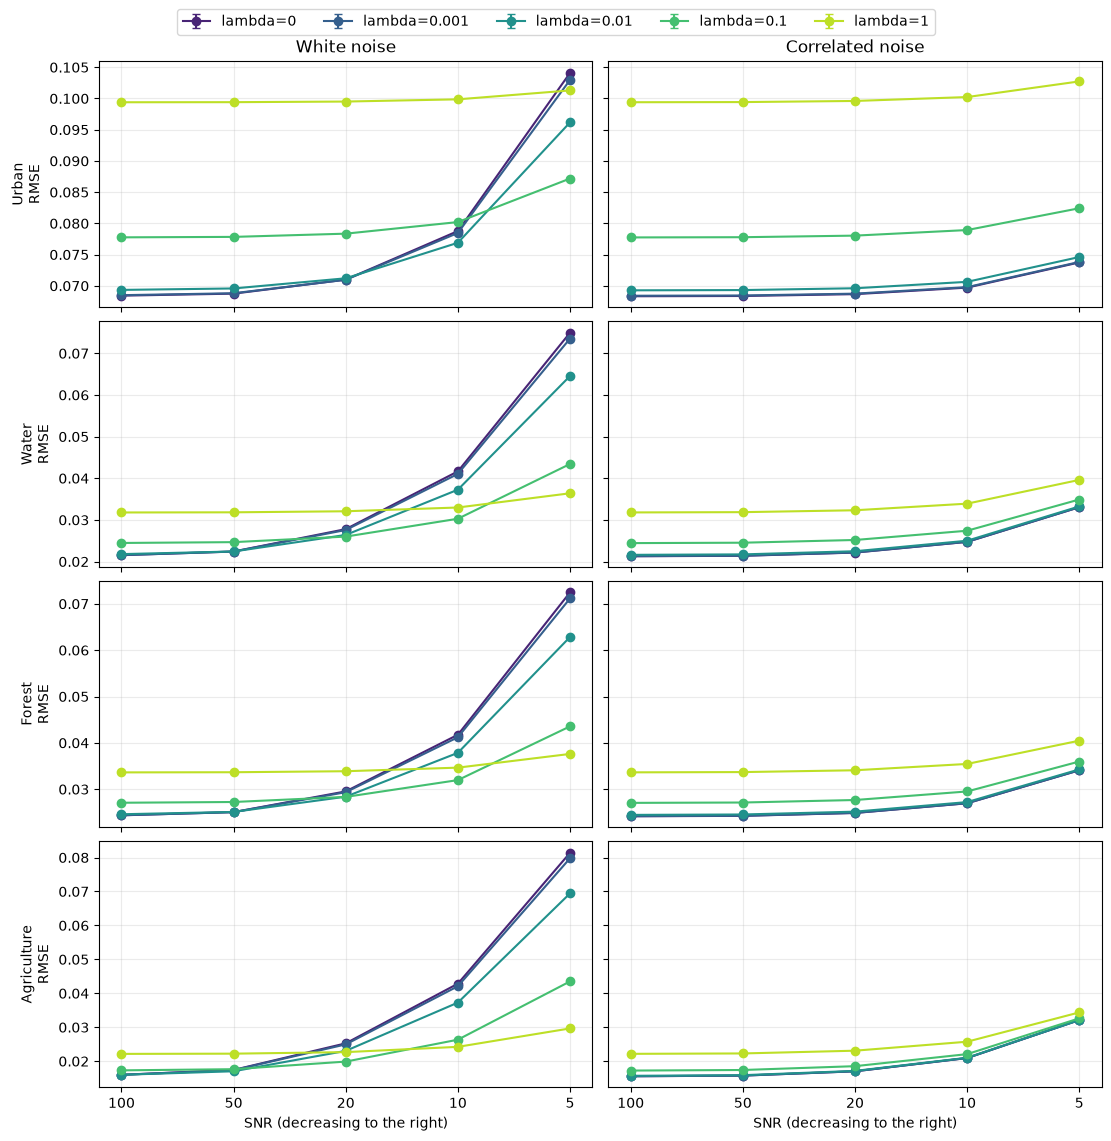

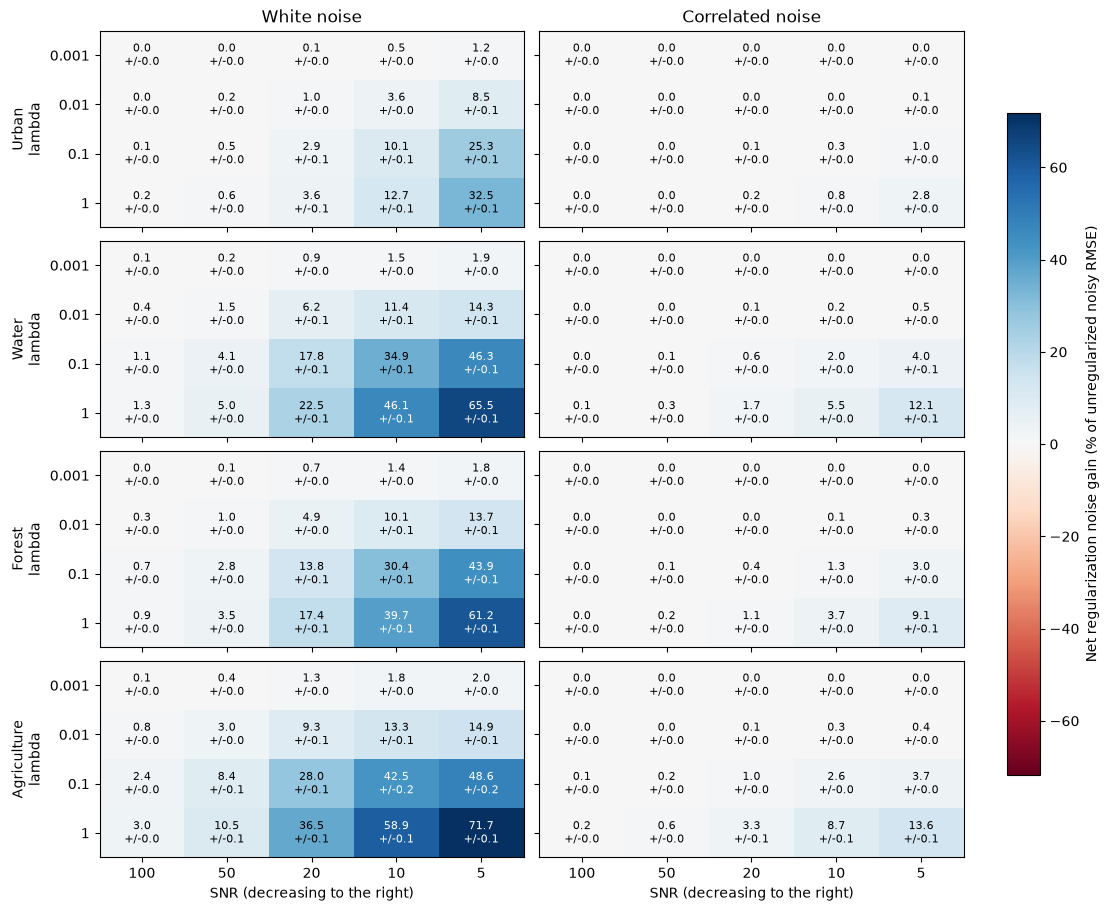

In [9]:
def plot_noise_rmse_vs_snr(summary):
    noisy = summary.loc[summary["noise_model"].ne("none")].copy()
    snr_order = [snr for snr in (100.0, 50.0, 20.0, 10.0, 5.0) if snr in noisy["snr"].values]
    x = np.arange(len(snr_order))
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(LAMBDA_VALUES)))
    fig, axes = plt.subplots(
        len(SCENES), len(NOISE_MODELS), figsize=(11, 11),
        sharex=True, sharey="row", constrained_layout=True,
    )
    for row, scene in enumerate(SCENES):
        for col, noise_model in enumerate(NOISE_MODELS):
            ax = axes[row, col]
            panel = noisy.loc[
                noisy["scene"].eq(scene) & noisy["noise_model"].eq(noise_model)
            ]
            for color, lam in zip(colors, LAMBDA_VALUES):
                curve = panel.loc[panel["lam"].eq(lam)].set_index("snr").reindex(snr_order)
                ax.errorbar(
                    x, curve["rmse_vs_no_psf"], yerr=curve["rmse_std"],
                    marker="o", capsize=3, linewidth=1.5, color=color,
                    label=f"lambda={lam:g}",
                )
            ax.grid(alpha=0.25)
            ax.set_xticks(x, [f"{snr:g}" for snr in snr_order])
            if row == 0:
                ax.set_title(f"{noise_model.capitalize()} noise")
            if col == 0:
                ax.set_ylabel(f"{scene.capitalize()}\nRMSE")
            if row == len(SCENES) - 1:
                ax.set_xlabel("SNR (decreasing to the right)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(LAMBDA_VALUES), bbox_to_anchor=(0.5, 1.03))
    fig.savefig(FIG_DIR / "noise_sensitivity_rmse_vs_snr.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / "noise_sensitivity_rmse_vs_snr.png", dpi=180, bbox_inches="tight")
    return fig


def plot_regularization_noise_gain(summary):
    data = summary.loc[
        summary["noise_model"].ne("none") & summary["lam"].gt(0.0)
    ].copy()
    snr_order = [snr for snr in (100.0, 50.0, 20.0, 10.0, 5.0) if snr in data["snr"].values]
    lambda_order = sorted(data["lam"].unique())
    max_abs = max(float(data["regularization_noise_gain_pct"].abs().max()), 1e-12)
    fig, axes = plt.subplots(
        len(SCENES), len(NOISE_MODELS), figsize=(11, 9),
        sharex=True, sharey=True, constrained_layout=True,
    )
    image = None
    for row, scene in enumerate(SCENES):
        for col, noise_model in enumerate(NOISE_MODELS):
            ax = axes[row, col]
            panel = data.loc[
                data["scene"].eq(scene) & data["noise_model"].eq(noise_model)
            ]
            mean = panel.pivot(index="lam", columns="snr", values="regularization_noise_gain_pct").reindex(index=lambda_order, columns=snr_order)
            std = panel.pivot(index="lam", columns="snr", values="regularization_noise_gain_pct_std").reindex(index=lambda_order, columns=snr_order)
            image = ax.imshow(mean.to_numpy(), cmap="RdBu", vmin=-max_abs, vmax=max_abs, aspect="auto")
            for i in range(len(lambda_order)):
                for j in range(len(snr_order)):
                    value = mean.iloc[i, j]
                    spread = std.iloc[i, j]
                    color = "white" if abs(value) > 0.55 * max_abs else "black"
                    ax.text(j, i, f"{value:.1f}\n+/-{spread:.1f}", ha="center", va="center", fontsize=8, color=color)
            ax.set_xticks(range(len(snr_order)), [f"{snr:g}" for snr in snr_order])
            ax.set_yticks(range(len(lambda_order)), [f"{lam:g}" for lam in lambda_order])
            if row == 0:
                ax.set_title(f"{noise_model.capitalize()} noise")
            if col == 0:
                ax.set_ylabel(f"{scene.capitalize()}\nlambda")
            if row == len(SCENES) - 1:
                ax.set_xlabel("SNR (decreasing to the right)")
    cbar = fig.colorbar(image, ax=axes, shrink=0.8)
    cbar.set_label("Net regularization noise gain (% of unregularized noisy RMSE)")
    fig.savefig(FIG_DIR / "noise_sensitivity_regularization_gain.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / "noise_sensitivity_regularization_gain.png", dpi=180, bbox_inches="tight")
    return fig


if RUN_EXPERIMENT:
    rmse_figure = plot_noise_rmse_vs_snr(noise_sensitivity)
    gain_figure = plot_regularization_noise_gain(noise_sensitivity)
